# Solución problema

<img src="./ProblemaEjemplo.png" width="600" alt="Diagrama de ejemplo">

Considere el diagrama de bloques presentado, vamos a resolverlo tanto de forma simbólica (analítica) y númerica. 

## Solución analítica

Para solucionar este problema de forma analítica primero vamos a declarar las variables simbólicas, en este caso, tenemos solo dos variables $K$ y $s$. 

In [99]:
import sympy as sp
s = sp.symbols('s')
K = sp.symbols('K')

Continuamos, construyendo la función de transferencia del bloque. 

In [100]:
tf1 = K / (s*(s+2))

Para calcular la función de transferencia del error(s) con R(s) se replantea el diagrama de bloques, como se muestra:

<img src="./Función de transferencia del error.png" width="600" alt="Diagrama de ejemplo">

In [101]:
Error_R_tf = 1/(tf1*5)
Error_R_tf = sp.simplify(Error_R_tf)
print(Error_R_tf)

s*(s + 2)/(5*K)


Con esta función podemos calcular el error al paso escalon. Recordemos que la función de respuesta es $R(t)=100t$. Uno puede obtener la transformada de laplace de la función dada utilizando la siguiente función:

In [102]:
t = sp.symbols('t')
# Define la función
R = 100 * t

# Calcula la transformada de Laplace
R_s = sp.laplace_transform(R, t, s)
print(R_s)

(100/s**2, 0, True)


Note que la variable R_s es una variable tipo tupla, la función está dada en el primer elemento de la tupla. 

In [103]:
print("La transformada de Laplace de R(t) = 100t es:", R_s[0])

La transformada de Laplace de R(t) = 100t es: 100/s**2


Cotinuamos ahora aplicando el teorema del valor último, para lo cual aplicamos la siguiente ecuación:
$$Error_{ss} = \lim_{s\to 0}s*R(s)*Error_{tf}(s)$$ 

In [104]:
Error_ss = s*R_s[0]*Error_R_tf
Error_ss = Error_ss.subs(s, 0)
print('El error es: ', Error_ss)

El error es:  40/K


Recuerde que, de acuerdo al enunciado, es deseado saber cual es el valor $K$ para el que el error es 0.01. Para esto, vamos a volver la variable Error_ss igual a zero, es decir, le vamos a restar 0.01, y luego vamos a resolver para K. 

In [105]:
Error_eq = Error_ss - 0.01
# Resolver la ecuación para K
solucion_K = sp.solve(Error_eq, K)

# Mostrar la solución
print(solucion_K[0])
K = solucion_K[0]

4000.00000000000


## Análisis de la respuesta

Para este punto ya tenemos el valor de K, ahora queremos estudiar la respuesta del controlador $m(s)$, para verificar si la salida es razonable.  

<img src="./SalidaDelControlador.png" width="600" alt="Diagrama de ejemplo">

Para hacer la simulación utilizaremos la librería de control y numpy, como se muestra: 

In [106]:
import control as ctl
import numpy as np
time = np.linspace(0, 8, 200)


Ahora procedemos a crear las funciones de transferencia, para ello utilizaremos la función tf de la librería de control. Note que tenemos tres bloques, luego son tres funciones de transferencia:

In [107]:
tf1 = 4000
tf2 = ctl.tf([1], [1, 2, 0])
tf3 = 5

Con estas funciones de transferencia calculamos la función de transferencia equivalente del diagrama de bloques:

In [108]:
TF = ctl.feedback(tf1, tf2*tf3)
print(TF)

<TransferFunction>: sys[39]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']


4000 s^2 + 8000 s
-----------------
s^2 + 2 s + 2e+04



Ahora queremos analizar la respuesta del controlador ante una entrada rampa R(t) = 100t, para eso utilizaremos la función forced_response, como se muestra:

In [109]:
t, m = ctl.forced_response(TF, T=time, U=100*time)

Ahora procedemos a graficar la respuesta del controlador con respecto al tiempo. Note que exportaremos la librería matplotlib.

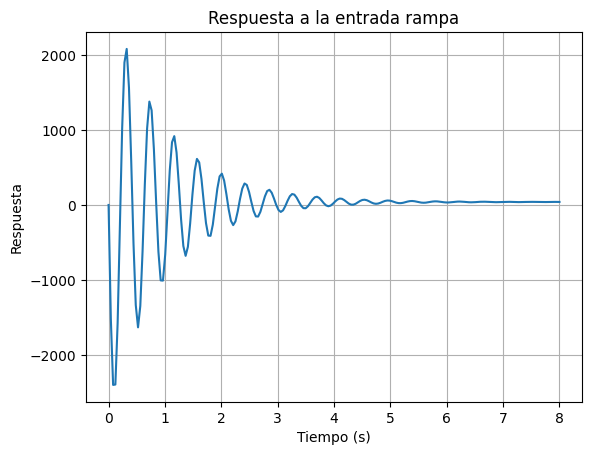

In [110]:
import matplotlib.pyplot as plt
plt.figure()
plt.plot(t, m)
plt.title('Respuesta del controlador a la entrada rampa')
plt.xlabel('Tiempo (s)')
plt.ylabel('Respuesta')
plt.grid(True)
plt.show()

## Problema

<img src="./Problema.png" width="600" alt="Diagrama de ejemplo">

Considere el diagrama presentado, el cual hace referencia a un sistema de calentamiento térmico. La función de transferencia que relaciona la temperatura de salida del sistema con el calor del calentador se encuentra dado. Considerenado que el fluido es agua, que el material del aislamiento es icopor, y que el sistema es una caja de 20x20x40 $cm^3$, implemente una estrategia de control proporcional que de un error de seguimiento a un paso escalón de temperatura del 1%, asuma que la dinámica del sensor de temperatura es despreciable y que su función de transferencia se puede representar como una unidad.  